In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
# Set figure parameters
sc.set_figure_params(dpi=100, vector_friendly=True) 
# vector_friendly=True rasterizes large objects (such as dots in a scatterplot as pixels).
# More at https://scanpy.readthedocs.io/en/stable/generated/scanpy.set_figure_params.html

## Data

In this session, we'll work with Xenium data from "Spatio-temporal interaction of immune and renal cells determines glomerular crescent formation in autoimmune kidney disease" [https://www.biorxiv.org/content/10.1101/2024.12.18.629206v1). The complete raw and processed data is available at [GSE294965](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE294965).

Since Xenium data can be quite big including images and cells (~3 million cells in this case & large images), here we'll work with data that contains 4 samples (2 controls, 2 ANCA-GN). 
This data is available at /home/shared/xenium_4donors.h5ad

ℹ️ Complete Xenium output for one of the slides can be viewed at /home/shared/MBI_BIA/Xenium_V1_FFPE_wildtype_2_5_months_outs/. It provides a nice analysis_summary.html. Go through it to familiarize with its content.  This is a Xenium data from mouse brain.

ℹ️ Xenium provides location of each transcript. Here, we are working with a data where transcripts are already aggregated for each cell. Each cell is segmented from DAPI channel of the morphology images (Read more on morphology images [here](https://www.10xgenomics.com/support/software/xenium-onboard-analysis/3.2/tutorials/outputs/xoa-output-understanding-outputs#images)) and refined with [Baysor](https://www.nature.com/articles/s41587-021-01044-w).

In [7]:
## read data
data = sc.read("/home/shared/spatial-workshop-GCB-2025/xenium_4donors.h5ad")

In [8]:
data

AnnData object with n_obs × n_vars = 198585 × 480
    obs: 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'x_centroid', 'y_centroid', 'cell_area', 'Slide_ID', 'Donor', 'Condition'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'

ℹ️ In this data, 480 genes were curated as Xenium v1 (as opposed to the recent Xenium Prime which includes a larger panel of 5000 pre-defined + 100 custom genes)

Caveat is: More genes result in less information per gene. See below the tech note from 10x Genomics.

![Xenium_v1_vs_5k_kidney](../images/xenium_v1_vs_5k.png)

Read complete technical note [here](https://cdn.10xgenomics.com/image/upload/v1721078232/support-documents/CG000775_Prime5K_DataHighlightsTN_RevA.pdf).

ℹ️ On a related note, two helpful papers for selecting spatial transcriptomics technology:

1. [A practical guide for choosing an optimal spatial transcriptomics technology from seven major commercially available options](https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-025-11235-3)
2. [Comparative analysis of multiplexed in situ gene expression profiling technologies](https://elifesciences.org/reviewed-preprints/96949)

In [12]:
data.obs.head()

,x,y,z,cluster,n_transcripts,density,elongation,area,avg_confidence,avg_assignment_confidence,max_cluster_frac,lifespan,x_centroid,y_centroid,cell_area,Slide_ID,Donor,Condition
cell_CR4f0dee9aa-8620,4618.841500,5301.182073,26.841818,1,11,1.2130,13.340,9.069,0.9748,0.9327,0.909091,50,4618.841500,5301.182073,9.069,0011762,X6_ANCA,ANCA-GN
cell_CR4f0dee9aa-8674,4599.426177,5336.510654,25.435634,1,13,0.9407,3.141,13.820,0.9914,0.9908,1.000000,50,4599.426177,5336.510654,13.820,0011762,X6_ANCA,ANCA-GN
cell_CR4f0dee9aa-8872,4594.233118,5376.025200,27.636609,1,17,0.8754,10.170,19.420,0.9901,0.9553,0.764706,50,4594.233118,5376.025200,19.420,0011762,X6_ANCA,ANCA-GN
cell_CR4f0dee9aa-8886,4677.768790,5292.878229,27.674027,4,21,0.6942,1.269,30.250,0.9932,0.9114,0.761905,50,4677.768790,5292.878229,30.250,0011762,X6_ANCA,ANCA-GN
cell_CR4f0dee9aa-8908,4686.502263,5287.558732,26.300427,2,19,0.6248,1.474,30.410,0.9923,0.9505,0.736842,50,4686.502263,5287.558732,30.410,0011762,X6_ANCA,ANCA-GN


## Information about data

1. data.X contains raw counts.  
2. Slide_ID in .obs contains a unique ID for each Xenium slide. Xenium slides are bigger (12 x 24 mm) compared to Visium v1 (6.5 x 6.5). It is common to include more than one biopsy on one slide. In the data we use, 8 samples from different donors were placed on the same slide. Slide_ID can be used as "batch". The data is here includes only 2 donors from ANCA-GN and 2 from control, so this complexity may not be visible. In practice, a tool like [Napari](https://napari.org/stable/) is used to cut biopsies of different donors.  
3. Condition in .obs contains donor's conditions. Here, samples are from Control or [ANCA-GN](https://unckidneycenter.org/kidneyhealthlibrary/glomerular-disease/anca-vasculitis/). Control samples are taken from healthy parts of a tumor samples.  
4. .obsm["spatial"] contains center-coordinates of each spot.  

In [16]:
## subset data so only the cells of the sample we are plotting are available
all_samples = data.obs["Donor"].unique()
sub = data[data.obs["Donor"]==all_samples[0]] # select first sample

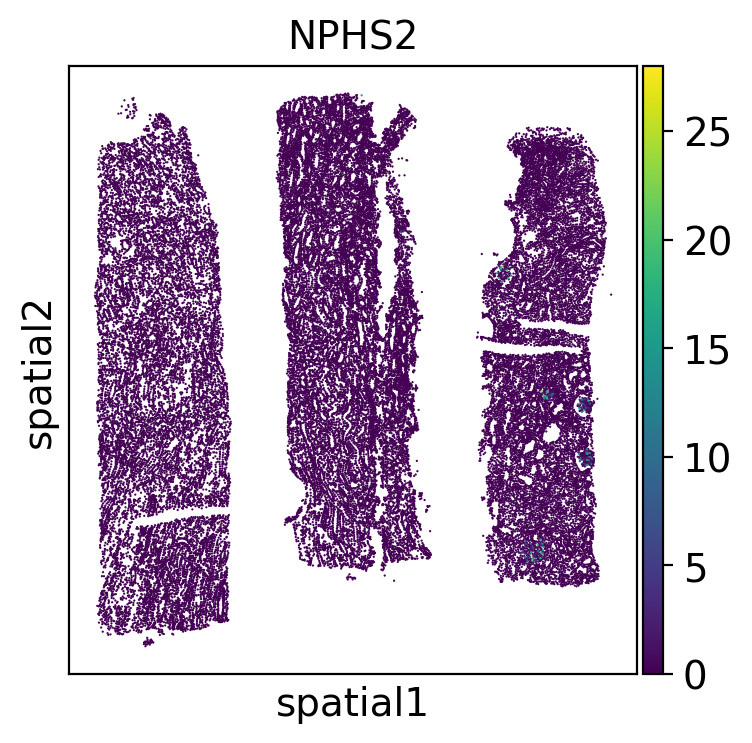

In [17]:
## Plotting
# Since there is no image stored in .uns["spatial"] as opposed to for Visium, we'll use pl.embedding here:

ax=sc.pl.embedding(sub, color="NPHS2", basis="spatial", show=False) # This uses coordinates from "spatial"
ax.invert_yaxis() 
plt.show()


In [21]:
## check maximum transcript per gene and maximum number of transcripts per cell
data.X.max(), data.X.sum(1).max()

(78.0, 482.0)

In [31]:
## Since the maximum number of transcripts is quite low, we will normalize each cells count to sum to median which is:
np.median(data.X.sum(axis=1).A1)

31.0

<u>Tasks:</u>

1. Process the data similar to visium: normalize to sum to median, log-normalize, compute PCA, batch correct with Harmony and compute UMAP.  
Note: Since we have only 480 genes, we won't compute highly variable genes.  
Save the resulting data to xenium_4donors_processed.h5ad

In [33]:
sc.pp.normalize_total(data, target_sum=31)
sc.pp.log1p(data)
sc.tl.pca(data)
sc.external.pp.harmony_integrate(data, key="Slide_ID", max_iter_harmony=50)
sc.pp.neighbors(data, use_rep="X_pca_harmony") # calculates neighborhood graph of spots using corrected PCs. use_rep can be any key in .obsm
sc.tl.umap(data)

2025-09-21 07:28:49,228 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-21 07:29:06,684 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-21 07:29:07,716 - harmonypy - INFO - Iteration 1 of 50
2025-09-21 07:30:37,992 - harmonypy - INFO - Iteration 2 of 50
2025-09-21 07:31:40,842 - harmonypy - INFO - Iteration 3 of 50
2025-09-21 07:32:06,863 - harmonypy - INFO - Converged after 3 iterations


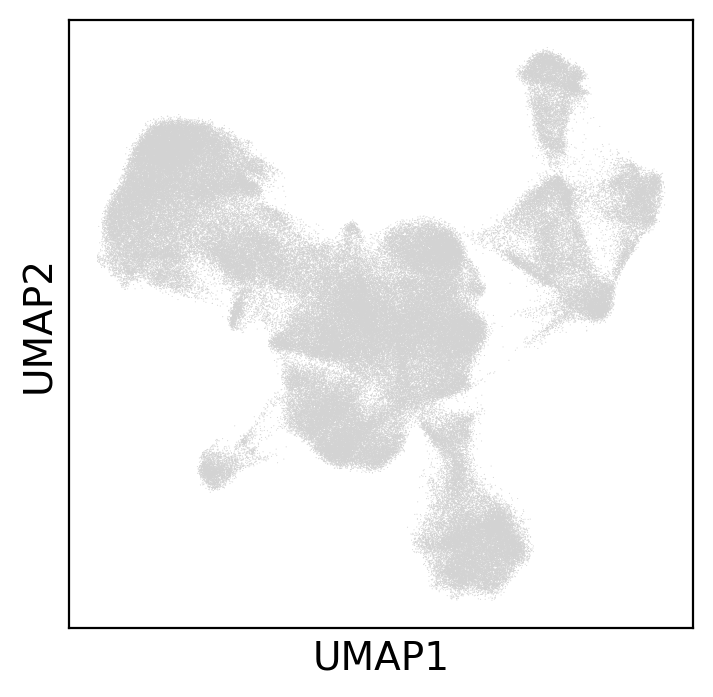

In [34]:
sc.pl.umap(data)

In [35]:
data.write("xenium_4donors_processed.h5ad")